In [29]:
from random import randint
import jax
import jax.numpy as jnp
from jax.scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

from uphate.uphate import pdist_squared
from uphate.mds import compute_metric_mds_embedding, mds_loss

In [ ]:
Y = jnp.array(
    [
        [1, 0],
        [0, 1],
        [1, 1],
        [0, 0],
    ],
    dtype=jnp.float32,
)
X = (
    jnp.concat([Y, jnp.ones((4, 1))], axis=1)
    @ Rotation.from_euler("xyz", jnp.array([90, 45, 20]), degrees=True).as_matrix()
)
X_alt = jnp.concat([Y, jnp.arange(1, 5, dtype=jnp.float32)[:, None]], axis=1)

(
    (pdist_squared(X) - pdist_squared(Y)).round(4),
    (pdist_squared(X_alt) - pdist_squared(Y)).round(4),
)

(Array([[ 0., -0., -0., -0.],
        [-0.,  0., -0., -0.],
        [-0., -0.,  0., -0.],
        [-0., -0., -0.,  0.]], dtype=float32),
 Array([[0., 1., 4., 9.],
        [1., 0., 1., 4.],
        [4., 1., 0., 1.],
        [9., 4., 1., 0.]], dtype=float32))

In [4]:
key, subkey = jax.random.split(jax.random.PRNGKey(0))

Y_init = jax.random.normal(subkey, shape=Y.shape)
Y_hat = compute_metric_mds_embedding(Y_init, X, key)
mds_loss(Y_hat, X, None)

Array(2.6022867e-08, dtype=float32)

In [8]:
import jaxopt

loss_grad = jax.grad(mds_loss, argnums=0)
mds_with_grad = jaxopt.implicit_diff.custom_root(loss_grad)(
    compute_metric_mds_embedding
)

In [9]:
(
    loss_grad(Y, X, None),
    loss_grad(Y_hat, X, None),
    loss_grad(Y_init, X, None),
)

(Array([[ 2.8779669e-07, -2.8779669e-07],
        [-4.0700598e-07,  2.8779669e-07],
        [ 2.3841858e-07,  1.1920929e-07],
        [-1.1920929e-07, -1.1920929e-07]], dtype=float32),
 Array([[ 2.1117261e-04, -1.0049686e-04],
        [-7.4139287e-05,  2.1083724e-04],
        [-2.2454005e-04, -1.9548085e-04],
        [ 8.7506734e-05,  8.5140462e-05]], dtype=float32),
 Array([[-6.106097  , -5.5699925 ],
        [ 4.226698  ,  1.7649858 ],
        [ 1.2224611 ,  0.23803289],
        [ 0.6569381 ,  3.5669737 ]], dtype=float32))

In [ ]:
k1, k2 = jax.random.key(randint(0, 100000)), jax.random.key(randint(0, 100000))


jac2 = jax.jacrev(mds_with_grad, argnums=1)(
    Y_init,
    X,
    subkey,
)

In [49]:
jac1 = jax.jacrev(mds_with_grad, argnums=1)(
    Y_init,
    X,
    subkey,
)
jac2 = jax.jacrev(mds_with_grad, argnums=1)(
    Y,
    X,
    subkey,
)
jac3 = jax.jacrev(mds_with_grad, argnums=1)(
    Y + 100,
    X,
    subkey,
)
jnp.abs(jac3 - jac2).max()

Array(1.1920929e-07, dtype=float32)

In [50]:
jac1.shape

(4, 2, 4, 3)

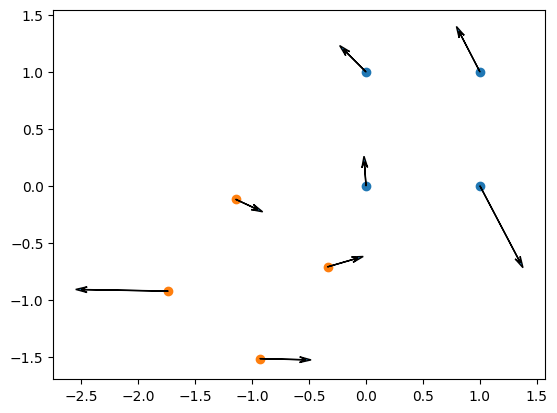

In [76]:
# Look at derivatives w.r.t first coordinate of first entry of X
x_entry, x_coord = 0, 2
grad_y_hat = jac1[:, :, x_entry, x_coord]
grad_y = jac2[:, :, x_entry, x_coord]


fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.scatter(*Y.T)
for point, arrow in zip(Y, grad_y):
    ax.arrow(*point, *arrow, head_width=0.05, head_length=0.1, overhang=0.5,)
ax.scatter(*Y_hat.T)
for point, arrow in zip(Y_hat, grad_y_hat):
    ax.arrow(*point, *arrow, head_width=0.05, head_length=0.1, overhang=0.5,)